In [6]:
import pandas as pd
import numpy as np
import math
import glob
import os
import scipy.stats
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from scipy import stats
import statsmodels.api as sm
from scipy.stats import norm, t
import time

In [7]:
parent_folder = ['/home/bvelasco/CovidVax_DM/Results/complete_data/gformula/struct_miss/out_modeltype_ML/presplit_chunks_100/*/*.csv']

In [8]:
def normality_tests(x, alpha=0.05):
    """
    Perform three normality tests on the data in x,
    then draw a Q–Q plot.
    
    Parameters
    ----------
    x : array‐like
        Vector of observations.
    alpha : float
        Significance level for Shapiro and D’Agostino.
    """
    x = np.asarray(x)
    n = x.size
    print(f"Sample size: {n}\n")

    # 1) Shapiro–Wilk
    stat_sw, p_sw = stats.shapiro(x)
    print(f"Shapiro–Wilk test:")
    print(f"  statistic = {stat_sw:.4f}, p‐value = {p_sw:.4g} -> "
          f"{'reject H0 (not normal)' if p_sw < alpha else 'fail to reject H0 (normal)'}\n")

    # 2) D’Agostino’s K²
    stat_dk, p_dk = stats.normaltest(x)
    print(f"D’Agostino’s K² test:")
    print(f"  statistic = {stat_dk:.4f}, p‐value = {p_dk:.4g} -> "
          f"{'reject H0 (not normal)' if p_dk < alpha else 'fail to reject H0 (normal)'}\n")

    # 3) Anderson–Darling
    ad = stats.anderson(x, dist='norm')
    print(f"Anderson–Darling test:")
    print(f"  statistic = {ad.statistic:.4f}")
    for sl, crit in zip(ad.significance_level, ad.critical_values):
        decision = 'reject H0' if ad.statistic > crit else 'fail to reject H0'
        print(f"   at {sl:.1f}% significance: critical = {crit:.4f}, {decision}")
    print()

    # 4) Q–Q plot
    sm.qqplot(x, line='45', fit=True)
    plt.title("Q–Q Plot vs. Normal")
    plt.tight_layout()
    plt.show()
    
    if (p_sw < alpha) and (p_dk < alpha):
        normal_data = False
    else:
        normal_data = True
    return normal_data

In [9]:
def check_sufficiently_large_sample(x):
    p_hat = np.mean(x)
    bottom = p_hat - 3*np.sqrt((p_hat*(1-p_hat))/len(x))
    up = p_hat + 3*np.sqrt((p_hat*(1-p_hat))/len(x))
    
    print((bottom, up))
    if bottom > 0.0 and up < 1.0:
        print('Sample sufficiently large, proportion is approximately normally distributed')
    else:
        print('Sample NOT sufficiently large, cannot assume proportion is normally distributed')
    
    return None

In [10]:
def mean_prop_ci(proportions, normal_data=True, alpha=0.05, method='z', n_boot=5000, random_state=None):
    """
    Compute a (1-alpha) confidence interval for the mean of a set of proportions.

    Parameters
    ----------
    proportions : array‐like of floats in [0,1]
        Your observed proportions p1, p2, …, pn.
    alpha : float, default=0.05
        Significance level (so 1-alpha is your CI coverage).
    method : {'z','t','bootstrap'}, default='z'
        'z'         – normal approximation (Z‐interval)
        't'         – Student's t‐interval
        'bootstrap' – non‐parametric percentile bootstrap
    n_boot : int, default=5000
        Number of bootstrap resamples (only used if method='bootstrap').
    random_state : int or None
        Seed for bootstrap RNG.

    Returns
    -------
    mean_hat : float
        The sample mean of your proportions.
    ci_lower : float
    ci_upper : float
        Lower/upper bounds of the (1-alpha) confidence interval.
    """
    if normal_data:
        p = np.asarray(proportions, dtype=float).flatten()
        n = p.size
        central_measure = p.mean()

        if method in ('z', 't'):
            # sample standard deviation of the proportions
            sd = p.std(ddof=1)
            se = sd / np.sqrt(n)

            if method == 'z':
                z = norm.ppf(1 - alpha/2)
                crit = z
            else:
                df = n - 1
                crit = t.ppf(1 - alpha/2, df)

            ci_lower = central_measure - crit * se
            ci_upper = central_measure + crit * se

        elif method == 'bootstrap':
            rng = np.random.default_rng(random_state)
            # draw bootstrap samples of size n with replacement, repeat n_boot times
            bs_idxs = rng.integers(0, n, size=(n_boot, n))
            bs_means = p[bs_idxs].mean(axis=1)
            ci_lower = np.percentile(bs_means, 100 * (alpha/2))
            ci_upper = np.percentile(bs_means, 100 * (1 - alpha/2))

        else:
            raise ValueError("For normal data method must be one of {'z','t','bootstrap'}")
    
    else:
        p = np.asarray(proportions, dtype=float).flatten()
        n = p.size
        central_measure = np.median(p)
        
        if method in ('z', 't'):
            # sample standard deviation of the proportions
            raise('IQR not implemented, use bootstrap')

        elif method == 'bootstrap':
            rng = np.random.default_rng(random_state)
            # draw bootstrap samples of size n with replacement, repeat n_boot times
            bs_idxs = rng.integers(0, n, size=(n_boot, n))
            bs_medians = np.median(p[bs_idxs], axis=1)
            ci_lower = np.percentile(bs_medians, 100 * (alpha/2))
            ci_upper = np.percentile(bs_medians, 100 * (1 - alpha/2))
            
        else:
            raise ValueError("For non-normal data method must be one of {'iqr','bootstrap'}")

    return central_measure, ci_lower, ci_upper

Intervention:
Natural course

Normality test:
Sample size: 100

Shapiro–Wilk test:
  statistic = 0.9682, p‐value = 0.0162 -> reject H0 (not normal)

D’Agostino’s K² test:
  statistic = 16.5845, p‐value = 0.0002505 -> reject H0 (not normal)

Anderson–Darling test:
  statistic = 1.0708
   at 15.0% significance: critical = 0.5550, reject H0
   at 10.0% significance: critical = 0.6320, reject H0
   at 5.0% significance: critical = 0.7590, reject H0
   at 2.5% significance: critical = 0.8850, reject H0
   at 1.0% significance: critical = 1.0530, reject H0



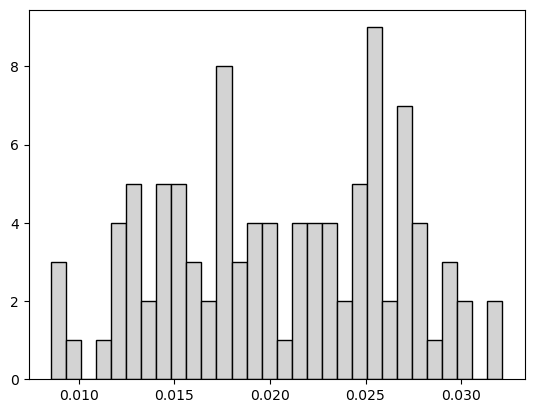

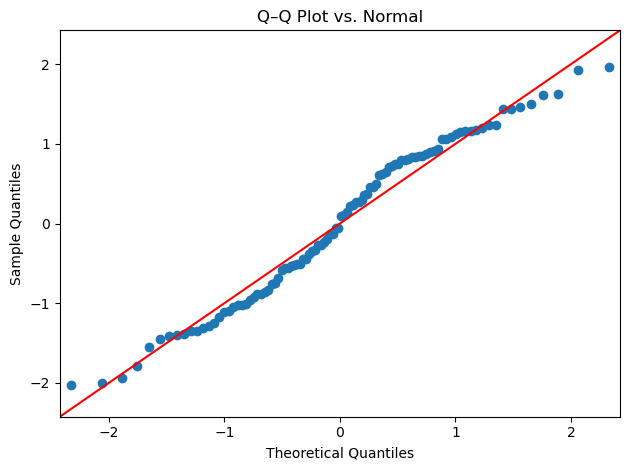

Using medians
Sample size test:
(-0.0220114024610518, 0.06307830597573441)
Sample NOT sufficiently large, cannot assume proportion is normally distributed

*********************************

Intervention:
Never treat

Normality test:
Sample size: 100

Shapiro–Wilk test:
  statistic = 0.6213, p‐value = 1.114e-14 -> reject H0 (not normal)

D’Agostino’s K² test:
  statistic = 78.0419, p‐value = 1.131e-17 -> reject H0 (not normal)

Anderson–Darling test:
  statistic = 13.2858
   at 15.0% significance: critical = 0.5550, reject H0
   at 10.0% significance: critical = 0.6320, reject H0
   at 5.0% significance: critical = 0.7590, reject H0
   at 2.5% significance: critical = 0.8850, reject H0
   at 1.0% significance: critical = 1.0530, reject H0



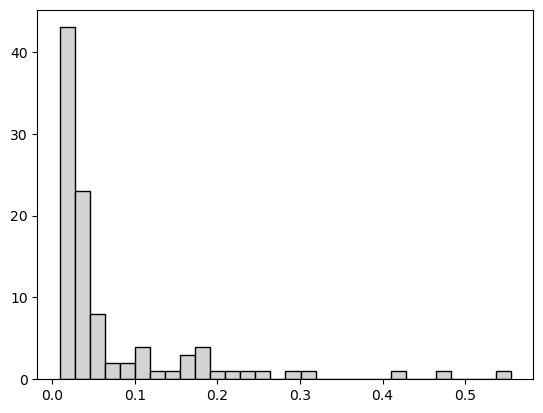

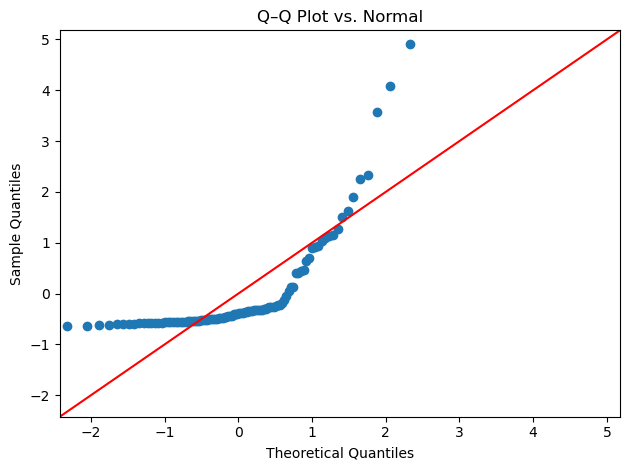

Using medians
Sample size test:
(-0.005081193783034538, 0.15092256856604455)
Sample NOT sufficiently large, cannot assume proportion is normally distributed

*********************************

Intervention:
Treat on Vacuna only at t1

Normality test:
Sample size: 100

Shapiro–Wilk test:
  statistic = 0.8303, p‐value = 2.361e-09 -> reject H0 (not normal)

D’Agostino’s K² test:
  statistic = 60.8102, p‐value = 6.241e-14 -> reject H0 (not normal)

Anderson–Darling test:
  statistic = 3.3177
   at 15.0% significance: critical = 0.5550, reject H0
   at 10.0% significance: critical = 0.6320, reject H0
   at 5.0% significance: critical = 0.7590, reject H0
   at 2.5% significance: critical = 0.8850, reject H0
   at 1.0% significance: critical = 1.0530, reject H0



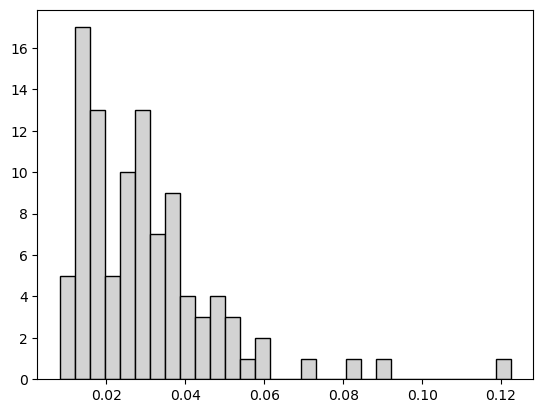

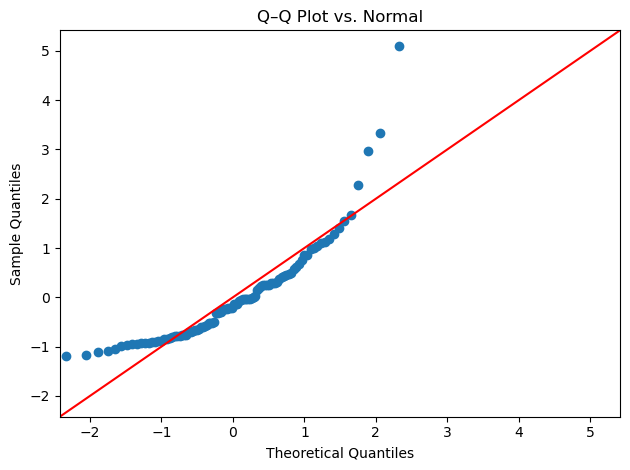

Using medians
Sample size test:
(-0.021175339155312486, 0.08118487541708577)
Sample NOT sufficiently large, cannot assume proportion is normally distributed

*********************************

Intervention:
Treat on Vacuna only at t1 & t2

Normality test:
Sample size: 100

Shapiro–Wilk test:
  statistic = 0.7788, p‐value = 5.808e-11 -> reject H0 (not normal)

D’Agostino’s K² test:
  statistic = 75.6843, p‐value = 3.676e-17 -> reject H0 (not normal)

Anderson–Darling test:
  statistic = 4.6500
   at 15.0% significance: critical = 0.5550, reject H0
   at 10.0% significance: critical = 0.6320, reject H0
   at 5.0% significance: critical = 0.7590, reject H0
   at 2.5% significance: critical = 0.8850, reject H0
   at 1.0% significance: critical = 1.0530, reject H0



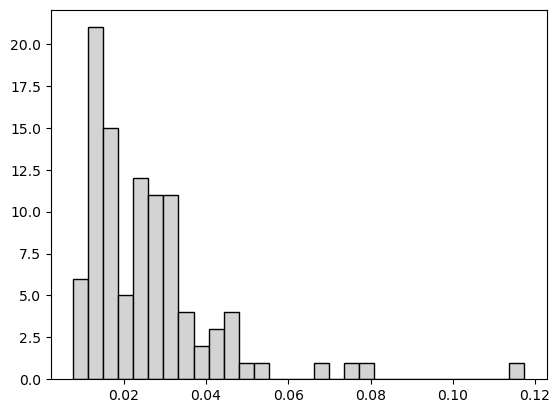

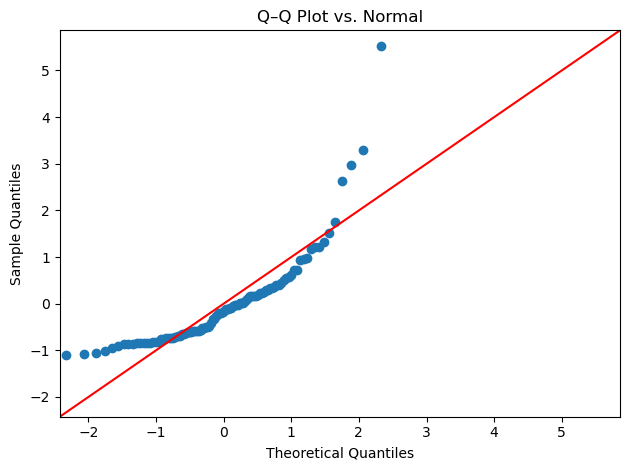

Using medians
Sample size test:
(-0.021752396781373924, 0.07352751662462853)
Sample NOT sufficiently large, cannot assume proportion is normally distributed

*********************************

Intervention:
Treat on Vacuna at t1, t2 & t3

Normality test:
Sample size: 100

Shapiro–Wilk test:
  statistic = 0.9925, p‐value = 0.8552 -> fail to reject H0 (normal)

D’Agostino’s K² test:
  statistic = 0.8496, p‐value = 0.6539 -> fail to reject H0 (normal)

Anderson–Darling test:
  statistic = 0.1911
   at 15.0% significance: critical = 0.5550, fail to reject H0
   at 10.0% significance: critical = 0.6320, fail to reject H0
   at 5.0% significance: critical = 0.7590, fail to reject H0
   at 2.5% significance: critical = 0.8850, fail to reject H0
   at 1.0% significance: critical = 1.0530, fail to reject H0



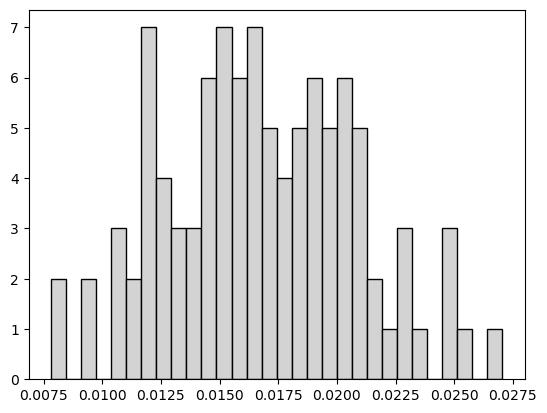

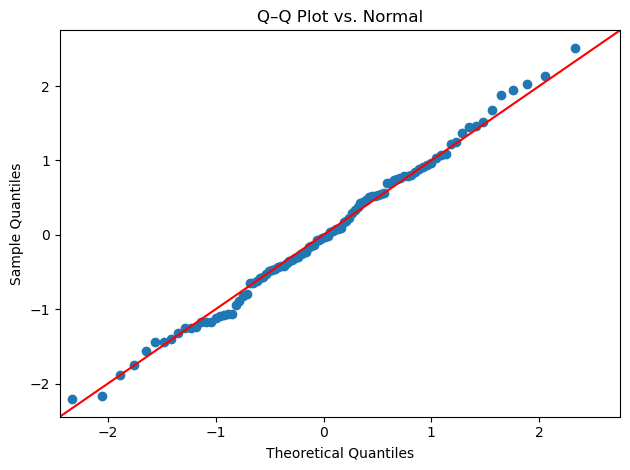

Sample size test:
(-0.021757493888079658, 0.0553741271339606)
Sample NOT sufficiently large, cannot assume proportion is normally distributed

*********************************



,Risk,Risk ratio,NP Probability
Natural course,"0.0207, (0.0184, 0.0229)","0.6625, (0.6167, 0.7176)",0.01824
Never treat,"0.0346, (0.0255, 0.0410)","1.0000, (1.0000, 1.0000)",NaN
Treat on Vacuna only at t1,"0.0267, (0.0225, 0.0294)","0.8736, (0.8525, 0.9233)",NaN
Treat on Vacuna only at t1 & t2,"0.0232, (0.0176, 0.0259)","0.7604, (0.7249, 0.7956)",NaN
"Treat on Vacuna at t1, t2 & t3","0.0168, (0.0160, 0.0176)","0.4985, (0.4472, 0.5480)",NaN


In [11]:
data=None
result_data = None
result_line = dict()
verbose = True
n_boot=1000

for _, folder in enumerate(parent_folder):
    
    result_files = glob.glob(folder)
    #print(result_files)

    # Read data
    for index, file  in enumerate(result_files):
        if index==0:
            data = pd.read_csv(file)
            data.drop(['Unnamed: 0'], inplace=True, axis=1)
            # Change the reference value from Natural Course to Never treat
            data['Mean ratio'] = data['Mean ratio']/data['Mean ratio'].values[1] 
        else:
            newdata = pd.read_csv(file)
            newdata.drop(['Unnamed: 0', 'Intervention'], inplace=True, axis=1)
            # Change the reference value from Natural Course to Never treat
            newdata['Mean ratio'] = newdata['Mean ratio']/newdata['Mean ratio'].values[1]
            if newdata.loc[1, 'Mean ratio']<20:
                data = pd.concat([data, newdata], axis=1)
            else:
                print(index)
                pass
            
    # Check difference between Param and NP means
    #print((data.loc[data['Intervention']=='Natural course', 'NP mean'].values - data.loc[data['Intervention']=='Natural course', 'g-form mean (NICE)'].values))
    #fig, ax = plt.subplots()
    #ax.plot(np.abs(data.loc[data['Intervention']=='Natural course', 'NP mean'].values - data.loc[data['Intervention']=='Natural course', 'g-form mean (NICE)'].values).flatten())
    #plt.show()
        
    # Compute statistics
    for intervention in data.Intervention.values:
        if verbose==True:
            print('Intervention:')
            print(intervention)
            print('')
            plt.hist(data[data['Intervention']==intervention]['g-form mean (NICE)'].values[0], bins=30, color='lightgrey', edgecolor='black')
            print('Normality test:')
            normal_data = normality_tests(data[data['Intervention']==intervention]['g-form mean (NICE)'].values[0])
            if not normal_data:
                print('Using medians')
            print('Sample size test:')
            check_sufficiently_large_sample(data[data['Intervention']==intervention]['g-form mean (NICE)'].values[0])
            print('')
            print('*********************************')
            print('')
        else:
            pass

        if intervention=='Natural course': # Include nonparametric estimate
            result_line[intervention] = [mean_prop_ci(data[data['Intervention']==intervention]['NP mean'].values, method='t')[0],
                                    mean_prop_ci(data[data['Intervention']==intervention]['g-form mean (NICE)'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[0],
                                    mean_prop_ci(data[data['Intervention']==intervention]['g-form mean (NICE)'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[1], 
                                    mean_prop_ci(data[data['Intervention']==intervention]['g-form mean (NICE)'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[2],
                                    mean_prop_ci(data[data['Intervention']==intervention]['Mean ratio'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[0],
                                    mean_prop_ci(data[data['Intervention']==intervention]['Mean ratio'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[1],
                                    mean_prop_ci(data[data['Intervention']==intervention]['Mean ratio'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[2]]
        else:
            result_line[intervention] = [None,
                                    mean_prop_ci(data[data['Intervention']==intervention]['g-form mean (NICE)'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[0],
                                    mean_prop_ci(data[data['Intervention']==intervention]['g-form mean (NICE)'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[1], 
                                    mean_prop_ci(data[data['Intervention']==intervention]['g-form mean (NICE)'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[2],
                                    mean_prop_ci(data[data['Intervention']==intervention]['Mean ratio'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[0],
                                    mean_prop_ci(data[data['Intervention']==intervention]['Mean ratio'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[1],
                                    mean_prop_ci(data[data['Intervention']==intervention]['Mean ratio'].values, normal_data=normal_data, method='bootstrap', n_boot=n_boot)[2]]

    result_data = pd.DataFrame(result_line).T
    result_data = result_data.set_axis(['NP Probability', 'Probability', '95% LCI Probability', '95% UCI Probability', 'Probability ratio', '95% LCI PR', '95% UCI PR'], axis=1)
      
    # Change output shape for paper/report
    result_data['Risk'] = result_data[['Probability', '95% LCI Probability', '95% UCI Probability']].apply(lambda x: "{:.4f}, ({:.4f}, {:.4f})".format(round(x.iloc[0], 4), round(x.iloc[1], 4), round(x.iloc[2], 4)), axis=1)
    result_data['Risk ratio'] = result_data[['Probability ratio', '95% LCI PR', '95% UCI PR']].apply(lambda x: "{:.4f}, ({:.4f}, {:.4f})".format(round(x.iloc[0], 4), round(x.iloc[1], 4), round(x.iloc[2], 4)), axis=1)
    
result_data[['Risk', 'Risk ratio', 'NP Probability']]
#result_data.to_csv(folder.split('*')[0] + 'aggregated_results.csv')